## Agentic AI : **지능형 공정 데이터 분석 시스템**의 진화

최신 **지능형 공정 데이터 분석 시스템**의 구조적 진화    
    공정 데이터 → Ontology → Knowledge Graph → GNN → LLM  
    이건 단순한 기술 나열이 아니라,  
데이터의 **의미 → 구조 → 학습 → 추론 → 설명**의 전 과정을 하나의 축으로 통합한 것임   

    🧭 전체 개념 지도(데이터 흐름 중심 구조)

    [공정 데이터]
      ↓
    [Ontology] — “무엇이 무엇인가”를 정의
      ↓
    [Knowledge Graph] — “무엇이 어떻게 연결되어 있는가”를 저장
      ↓
    [GNN] — “관계 속에서 어떤 패턴이 존재하는가”를 학습
      ↓
    [LLM + RAG] — “학습된 패턴을 언어로 해석하고 설명”


Knowledge Graph(KG)가 **SPARQL 질의 엔진(Fuseki 등)** 과 연결되는 **저장·질의 경로**가 명시되도록 수정한 데이터 흐름도

> 인용구 추가



    Process Data Lake (Sensor, Equipment, Quality, Logs)
        │
        ▼
    Ontology  ─────┐
        │         │ Ontology 정의 기반 schema 반영
        ▼         │
    Knowledge Graph ──▶ Triple Store / SPARQL Endpoint (e.g., Fuseki, GraphDB)
        │                          │
        ▼                          ▼
      GNN  ◀───────────────  SPARQL Queries / Inference
        │
        ▼
      RAG / LLM ──▶ Reports, Alerts, Knowledge Feedback


🧭 핵심 연결 설명  
| 연결                           | 역할                                     |
| ---------------------------- | -------------------------------------- |
| **KG → Triple Store/SPARQL** | 온톨로지 구조를 반영한 RDF triple 저장 및 질의 가능하게 함 |
| **SPARQL → GNN/LLM**         | KG 내 관계를 조회·추론하거나 그래프 데이터로 변환          |
| **LLM → SPARQL**             | 자연어 질의를 SPARQL로 변환해 KG에서 정답 탐색         |
| **Feedback Loop**            | LLM이 추론 결과를 다시 Ontology/KG에 반영 (지식 갱신) |


### ⚙️ 1. 공정 데이터 (Process Data)

목표: 센서, 설비, 품질, 로그 데이터를 의미 있는 구조로 해석할 수 있도록 정리

📊 데이터 형태 예시
| 구분     | 예시                   |
| ------ | -------------------- |
| 시간 데이터 | 센서ID, 시각, 온도, 압력, 전류 |
| 이벤트 로그 | 장비동작, 알람, 경고, 유지보수   |
| 품질 데이터 | Lot ID, 검사 결과, 수율    |
| 매핑 정보  | 설비 → 공정라인 → 제품       |
  

🔍 문제점

데이터 간 의미적 연결이 약함

센서명, 코드명이 불규칙적

공정별 데이터가 단절되어 있음

→ Ontology가 이 문제를 해결하는 첫 단계!  

### 🧩 2. Ontology (온톨로지)

공정 도메인의 개념·관계·속성을 명세적으로 정의하는 “지식의 설계도”

    🏗️ 예시 정의
    클래스:  Line, Equipment, Sensor, Parameter, Alarm
    관계:
      hasSensor(Line → Sensor)
      measures(Sensor → Parameter)
      triggers(Parameter → Alarm)
      locatedIn(Sensor → Equipment)
    속성:
      value, timestamp, unit


이걸 Protégé에서 OWL/RDF로 모델링하면,
각 개체 간의 의미적 관계 구조가 생기고   
→ 이를 실제 데이터로 연결하면 Knowledge Graph가 됩니다.

### 🕸️ 3. Knowledge Graph (지식 그래프)

Ontology를 바탕으로 실제 공정 데이터를 연결한 그래프

📘 예시 (Triple 구조)  

    (라인1, hasSensor, 온도센서A)
    (온도센서A, measures, 온도)
    (온도센서A, value, 82.3)
    (온도, triggers, 과열경보)


이런 triple 수천 개가 연결되어 하나의 지식 네트워크를 형성합니다.
→ Fuseki, Neo4j, GraphDB 같은 Triple Store에 저장
→ SPARQL 질의로 추론:

    SELECT ?line ?sensor ?alarm
    WHERE {
      ?line ex:hasSensor ?sensor .
      ?sensor ex:measures ?param .
      ?param ex:triggers ?alarm .
      ?sensor ex:value ?v .
      FILTER(?v > 80)
    }


👉 과열경보 조건을 만족하는 모든 라인 조회

### 🔮 4. GNN (Graph Neural Network)

Knowledge Graph의 관계적 구조를 수치적으로 학습하는 엔진

🌐 데이터 변환

RDF → NetworkX → PyTorch Geometric 그래프 변환:

    노드: Line1, SensorA, Parameter(온도), Alarm(과열)
    엣지: (Line1, SensorA), (SensorA, Parameter), (Parameter, Alarm)
    노드 특징: 최근 센서값, 설비상태, 품질지표

🤖 GNN 학습 목표

| Task            | 설명          | 예시                          |
| --------------- | ----------- | --------------------------- |
| **노드 분류**       | 장비/센서 상태 예측 | “이 센서는 정상인가?”               |
| **링크 예측**       | 새로운 관계 추론   | “이 센서와 어떤 파라미터가 연관될까?”      |
| **서브그래프 패턴 학습** | 이상 패턴 탐지    | “이 라인의 연결 패턴은 과거 불량과 유사한가?” |

💡 사용 모델 예시

R-GCN (Relational Graph Convolutional Network) : 관계 타입별 메시지 전달

CompGCN : 관계 임베딩 합성

GAT / HGT : Attention 기반 중요 관계 가중치 학습

### 🧠 5. LLM (대형언어모델) 활용  

    GNN이 학습한 패턴을 ‘언어적 지식’으로 통합·해석

    📎 활용 방법

| 구분                                       | 내용                                            |
| ---------------------------------------- | --------------------------------------------- |
| **RAG (Retrieval-Augmented Generation)** | KG/SPARQL 질의를 LLM으로 생성 → 결과 해석                |
| **Graph Reasoning Agent**                | LLM이 Ontology 구조를 이해하고 SPARQL 작성              |
| **Explainable AI**                       | GNN의 결과를 LLM이 자연어로 해설 (“이 센서는 과열 패턴과 유사합니다.”) |
| **Knowledge Fusion**                     | LLM이 새로운 triple을 제안하거나 Ontology 확장            |
| **LangGraph**                            | LLM 에이전트들이 GNN·Fuseki와 연동되어 파이프라인 자동화         |


### 🔁 6. 전체 통합 파이프라인
    graph LR   
    A[공정 Data Lake<br>(센서, 장비, 품질, 로그)]
    --> B[Ontology 정의<br>(OWL/RDF, Protégé)]
    B --> C[Knowledge Graph<br>(Fuseki, GraphDB)]
    C --> D[GNN 학습<br>(R-GCN, PyG)]
    D --> E[LLM 해석·RAG 질의<br>(LangChain, LangGraph)]
    E --> F[자동 보고/경보/지식 업데이트]
    F --> B

🔄 설명

B → C: 의미적 모델을 실제 데이터에 매핑

C → D: 관계 구조를 수치화하여 학습

D → E: GNN의 예측 결과를 LLM이 해석

E → F → B: 새로운 지식을 다시 Ontology에 반영 (지식 순환)

### 🏭 7. 예시 시나리오 (제조공정용)  
| 단계 | 내용                                         |
| -- | ------------------------------------------ |
| ①  | 센서 로그 수집: 온도, 압력, 전류                       |
| ②  | Ontology 정의: Sensor–Parameter–Alarm 관계     |
| ③  | RDF로 Knowledge Graph 생성                    |
| ④  | GNN이 과거 데이터에서 “과열 전조 패턴” 학습                |
| ⑤  | LLM이 SPARQL 질의를 자동 생성: “최근 10분 내 유사 패턴 탐색” |
| ⑥  | 결과를 자연어 보고서로 생성: “라인3의 온도센서A가 과열 가능성 82%”  |

### 🧭 8. 요약
| 단계                  | 역할                                | 주요 기술                     |
| ------------------- | --------------------------------- | ------------------------- |
| **공정 데이터**          | 원시 데이터                            | 센서 로그, 품질 리포트             |
| **Ontology**        | 의미 모델                             | OWL, Protégé              |
| **Knowledge Graph** | 데이터 관계화                           | RDF, Fuseki, SPARQL       |
| **GNN**             | 패턴 학습                             | R-GCN, PyG, DGL           |
| **LLM**             | 질의, 해석, 설명                        | LangChain, LangGraph, RAG |
| **통합 목표**           | 데이터 → 지식 → 추론 → 설명의 순환형 지능 시스템 구축 |                           |


🌟 결론 요약

Ontology는 데이터의 의미를 정의하고,  
Knowledge Graph는 의미를 연결하며,  
GNN은 그 관계 속 패턴을 학습하고,  
LLM은 그 학습 결과를 언어적으로 해석하여  
“설명 가능한 공정 지능 시스템”을 완성한다.

# 통합 아키텍처 다이어그램
### mermaid url https://mermaid.live

## 공정 데이터 Ontology + KG + GNN + LLM 통합 아키텍처 다이어그램

In [ ]:
# flowchart TD
#   %% ===== 스타일 정의 =====
#   classDef data fill:#e6f2ff,stroke:#4d94ff,color:#003366,stroke-width:1.5,rx:8,ry:8
#   classDef model fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:8,ry:8
#   classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:8,ry:8

#   %% ===== 노드 =====
#   A["🏭 공정 데이터\n(Sensor · Equipment · Quality · Logs)"]
#   B["🧩 Ontology\n(개념·관계 정의, OWL/RDF)"]
#   C["🕸️ Knowledge Graph\n(RDF Triple, Fuseki, GraphDB)"]
#   D["🔍 SPARQL Endpoint\n(/sparql 질의 및 추론)"]
#   E["🧠 GNN 모델\n(R-GCN · GAT · HGT)"]
#   F["💬 LLM / RAG Agent\n(LangChain · LangGraph)"]
#   G["🔁 Feedback Loop\n(지식·규칙 갱신 및 자동 보고)"]

#   %% ===== 연결 =====
#   A -->|데이터 정제/매핑| B
#   B -->|RDF/TTL 생성| C
#   C -->|Triple 저장| D
#   D -->|질의/추론 결과| E
#   E -->|패턴·예측 임베딩| F
#   F -->|자연어 보고·의사결정| G
#   G -->|온톨로지·룰 업데이트| B

#   %% ===== 클래스 지정 =====
#   class A data
#   class B,C,D model
#   class E,F,G logic


| 단계                      | 핵심 역할               |
| ----------------------- | ------------------- |
| 🏭 **공정 데이터**           | 센서, 장비, 품질 로그 수집    |
| 🧩 **Ontology**         | 개념·관계 정의 (의미 모델)    |
| 🕸️ **Knowledge Graph** | RDF triple로 지식화     |
| 🔍 **SPARQL**           | 질의/추론, KG에서 정보 검색   |
| 🧠 **GNN**              | 관계 기반 패턴 학습         |
| 💬 **LLM**              | 질의, 설명, 보고 자동화      |
| 🔁 **Feedback**         | 룰·지식 갱신 (지속적 개선 루프) |


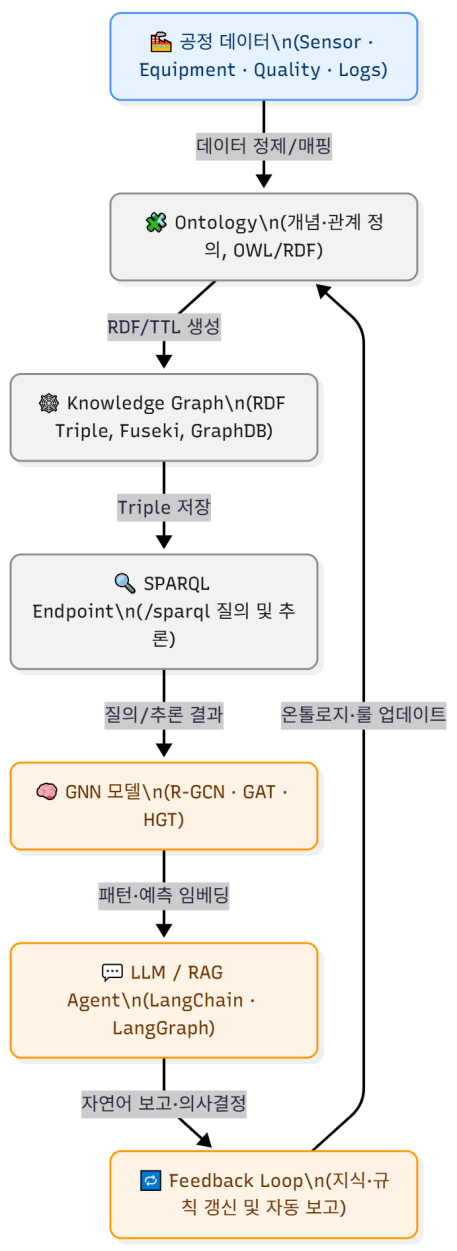

## 산업용 End-to-End 지능형 공정 시스템 구조도(자세한 흐름도)
산업용 색상 팔레트(파랑=데이터 / 회색=지식모델 / 주황=지능처리) 를 유지하면서  
공정 데이터 → Ontology → Knowledge Graph(SPARQL) → GNN → LLM → Feedback 까지의  
세부 경로와 내부 컴포넌트까지 모두 포함한 “자세한 버전”

    🎯 구조 설명
    계층	주요 구성 요소	역할
    공정 데이터 계층	센서, 장비, 품질 로그	실시간 데이터 수집 및 정제
    온톨로지 계층	Protégé, OWL, SHACL	의미적 개념 정의 및 규칙 설정
    지식그래프 계층	RDF Triple, Fuseki, SPARQL	지식 저장 및 논리 추론
    그래프 학습 계층(GNN)	R-GCN, GAT, CompGCN	관계 기반 이상 탐지 및 패턴 학습
    LLM / RAG 계층	LangChain, LangGraph	질의 해석, 보고서 생성, 설명 가능 AI
    피드백 루프	Human-in-the-loop	지식 갱신 및 지속적 학습
    🎨 색상 의미
    색상	의미	적용 범위
    파랑 (#4d94ff)	데이터의 신뢰성·안정성	공정 데이터 계층
    회색 (#8c8c8c)	지식 모델의 구조적 견고함	Ontology / KG
    주황 (#ff9900)	지능적 처리, 추론, 학습	GNN / LLM / Feedback

In [ ]:
# flowchart TD
# %% ===== 스타일 정의 =====
# classDef data fill:#e6f2ff,stroke:#4d94ff,color:#003366,stroke-width:1.5,rx:8,ry:8
# classDef model fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:8,ry:8
# classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:8,ry:8

# %% ===== 1) DATA INGESTION =====
# subgraph A["🏭 공정 데이터 계층 (Process Data Layer)"]
# direction TB
# A1["센서 로그\n(Temperature · Pressure · Vibration)"]
# A2["장비 운영 로그\n(운전, 정지, Alarm Event)"]
# A3["품질·검사 데이터\n(Defect Rate, Yield, SPC)"]
# A4["데이터 파이프라인\n(ETL · Kafka · Flink · OPC-UA)"]
# A1 --> A4
# A2 --> A4
# A3 --> A4
# end
# class A,A1,A2,A3,A4 data

# %% ===== 2) ONTOLOGY =====
# subgraph B["🧩 온톨로지 계층 (Ontology Layer)"]
# direction TB
# B1["도메인 개념 정의\n(Line, Equipment, Sensor, Parameter, Alarm)"]
# B2["관계 정의\n(hasSensor, measures, triggers, locatedIn)"]
# B3["제약 및 규칙\n(SHACL / SWRL)"]
# B4["모델링 도구\n(Protégé, OWL/RDF Schema)"]
# B1 --> B2 --> B3 --> B4
# end
# class B,B1,B2,B3,B4 model

# A4 -->|정제/매핑 데이터| B1

# %% ===== 3) KNOWLEDGE GRAPH =====
# subgraph C["🕸️ 지식그래프 계층 (Knowledge Graph Layer)"]
# direction TB
# C1["RDF Triple 생성\n(subject, predicate, object)"]
# C2["Triple Store\n(Fuseki · GraphDB · Stardog)"]
# C3["SPARQL Endpoint\n(/sparql)"]
# C4["Reasoner\n(OWL/SHACL 기반 추론)"]
# C1 --> C2 --> C3
# C4 --> C2
# C2 --> C4
# end
# class C,C1,C2,C3,C4 model

# B4 -->|Ontology 기반 RDF| C1

# %% ===== 4) GRAPH LEARNING (GNN) =====
# subgraph D["🧠 그래프 학습 계층 (Graph Learning Layer)"]
# direction TB
# D1["Graph Export\n(RDF → NetworkX/PyG 변환)"]
# D2["GNN Trainer\n(R-GCN · GAT · HGT · CompGCN)"]
# D3["Feature Store\n(Node/Edge Embedding 저장소)"]
# D4["패턴·이상 탐지\n(Link Prediction, Anomaly Detection)"]
# D1 --> D2 --> D3 --> D4
# end
# class D,D1,D2,D3,D4 logic

# C2 -->|RDF dump / CONSTRUCT 질의| D1

# %% ===== 5) LLM / RAG =====
# subgraph E["💬 지능형 추론 계층 (LLM / RAG Layer)"]
# direction TB
# E1["LLM Agent\n(LangChain · LangGraph)"]
# E2["RAG Pipeline\n(Graph + 문서 결합 검색)"]
# E3["자연어 질의 해석 → SPARQL 변환"]
# E4["보고서/경보 생성\n(Dashboard, ChatOps, BPMN 자동화)"]
# E1 --> E2 --> E3 --> E4
# end
# class E,E1,E2,E3,E4 logic

# D4 -->|예측 결과/임베딩| E1
# C3 <--> |SPARQL 질의 / 응답| E3

# %% ===== 6) FEEDBACK LOOP =====
# subgraph F["🔁 피드백 루프 (Knowledge Feedback Loop)"]
# direction TB
# F1["지식 검증 및 전문가 피드백"]
# F2["온톨로지/규칙 갱신"]
# F3["학습 데이터 업데이트\n(모델 재학습)"]
# F1 --> F2 --> F3
# end
# class F,F1,F2,F3 logic

# E4 -->|사용자 평가 / 결과| F1
# F2 -->|Ontology 업데이트| B1
# F3 -->|재학습 데이터| D2


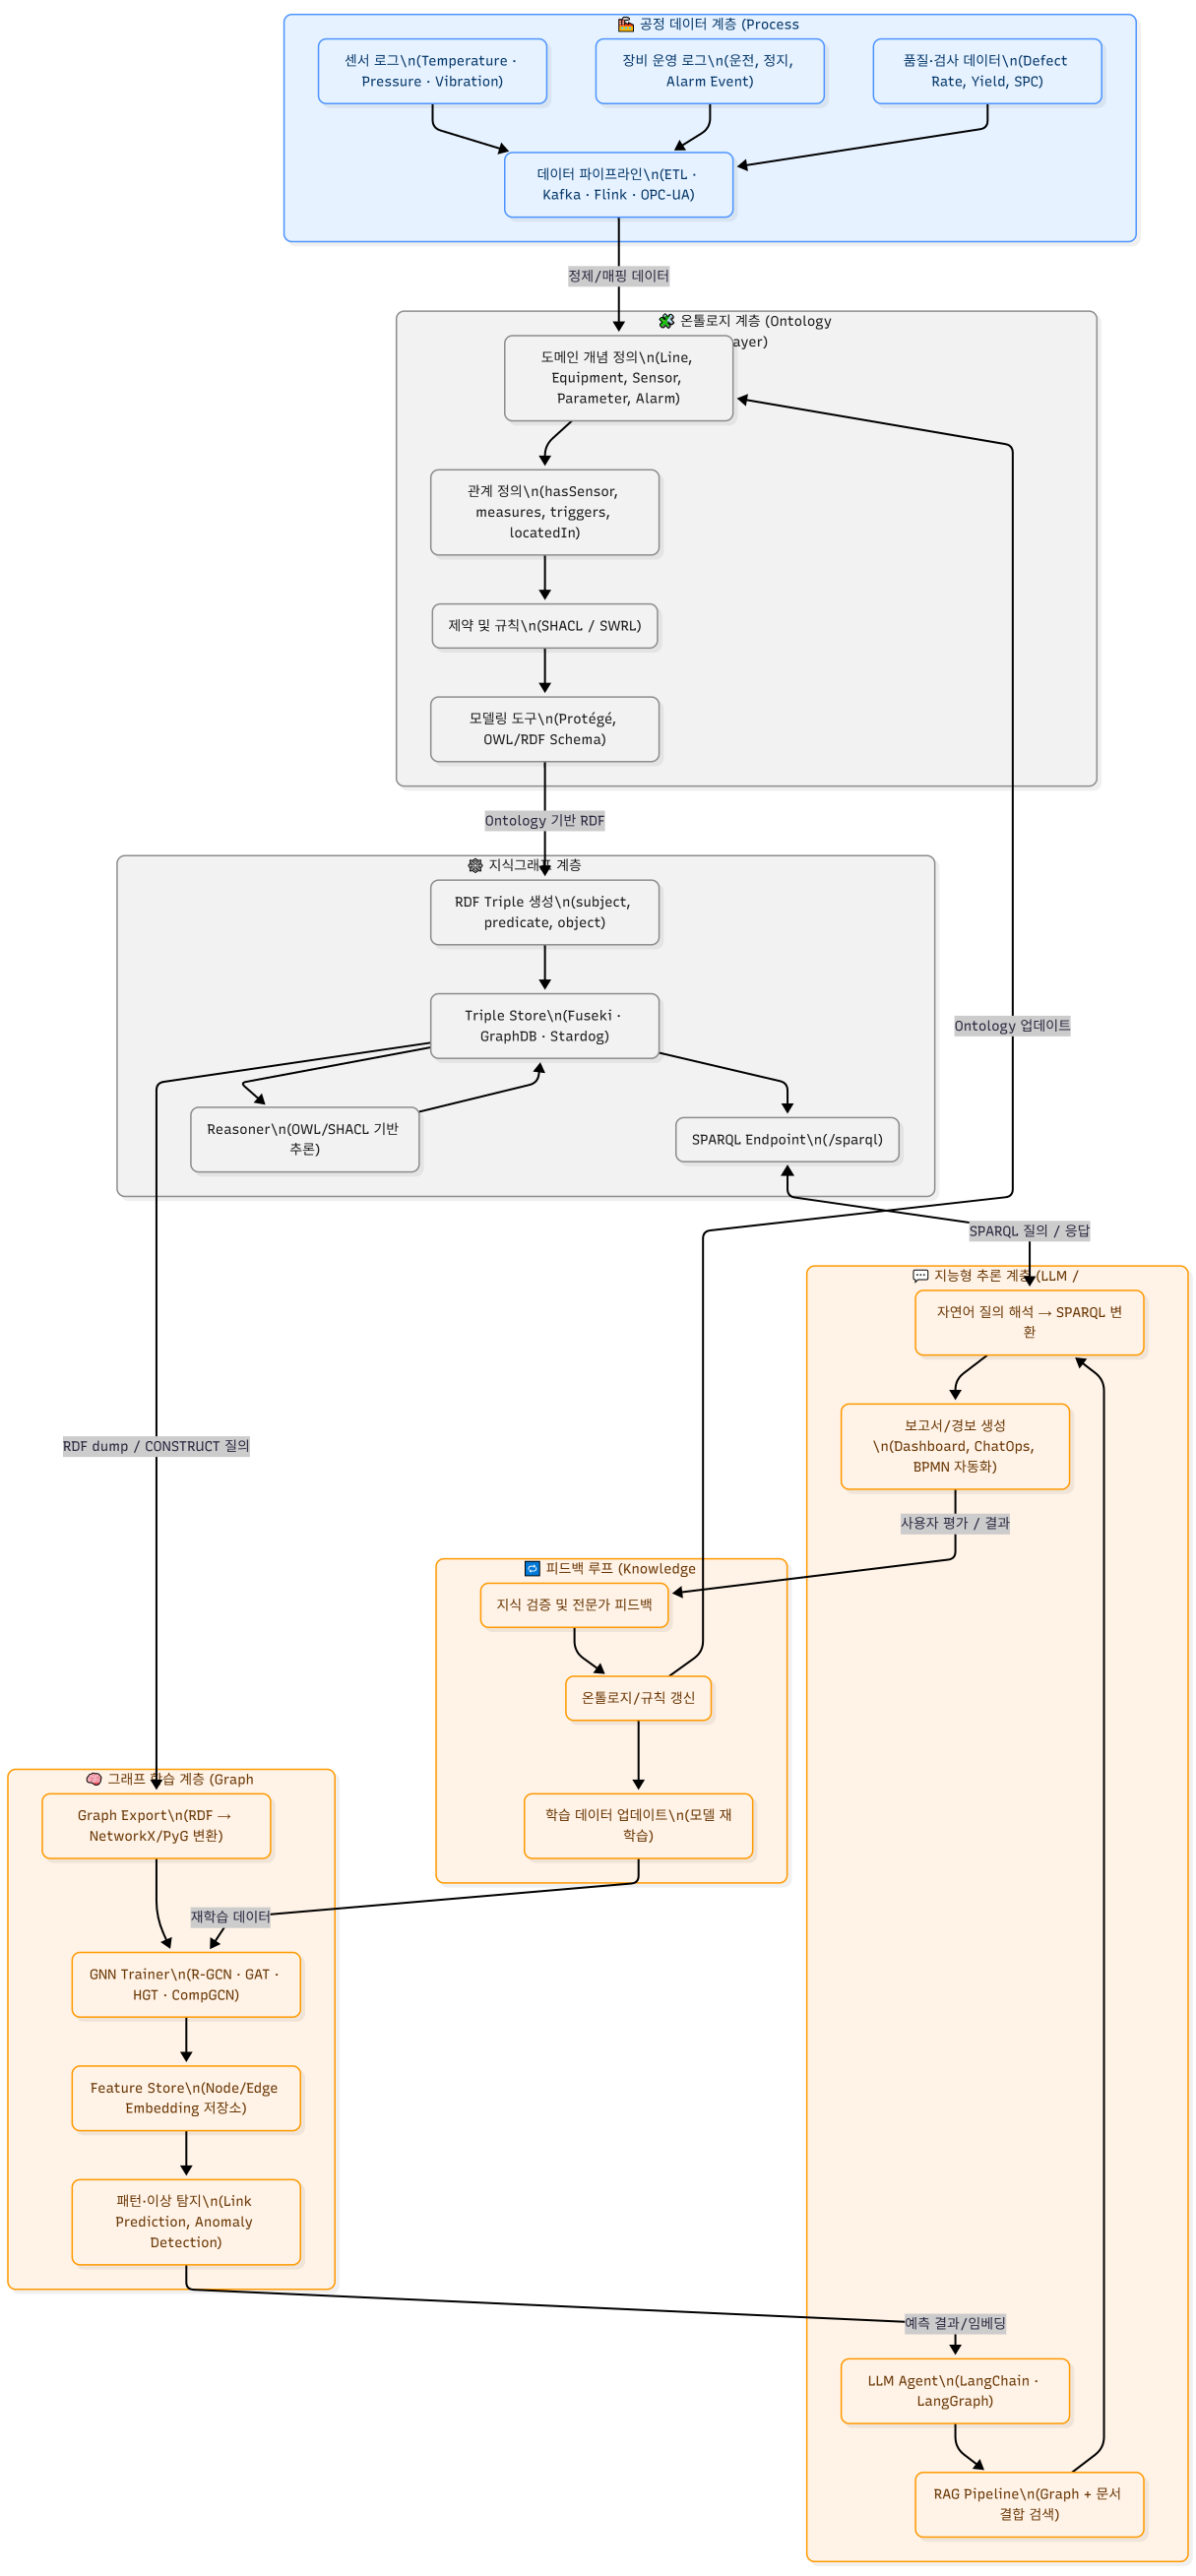

## SPARQL ↔ GNN ↔ LLM 간 양방향 데이터 흐름 강조선 (두꺼운 화살표) 버전   

SPARQL ↔ GNN ↔ LLM 구간의 양방향 데이터 흐름을
굵은 화살표(==>, <==>)로 강조한 형태

“KG 질의 → GNN 입력 → LLM 해석 → SPARQL 재질의”의  
**순환형 지식·추론 파이프라인**을 명확히 표현  

| 구분               | 내용                                                |
| ---------------- | ------------------------------------------------- |
| **SPARQL ↔ GNN** | GNN이 SPARQL을 통해 KG에서 그래프를 추출하고, 예측 결과를 다시 KG에 반영  |
| **GNN ↔ LLM**    | LLM이 GNN의 임베딩·예측결과를 해석하고, 자연어 질의를 GNN context로 보냄 |
| **LLM ↔ SPARQL** | LLM이 자연어 질의를 SPARQL로 변환하여 KG로부터 정보를 검색            |


In [ ]:
# flowchart TD
# %% ===== 스타일 정의 =====
# classDef data fill:#e6f2ff,stroke:#4d94ff,color:#003366,stroke-width:1.5,rx:8,ry:8
# classDef model fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:8,ry:8
# classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:8,ry:8

# %% ===== 1) DATA INGESTION =====
# subgraph A["🏭 공정 데이터 계층 (Process Data Layer)"]
# direction TB
# A1["센서 로그\n(Temperature · Pressure · Vibration)"]
# A2["장비 운영 로그\n(Operation · Alarm Events)"]
# A3["품질 데이터\n(Defect Rate · Yield)"]
# A4["데이터 파이프라인\n(ETL · Kafka · Flink)"]
# A1 --> A4
# A2 --> A4
# A3 --> A4
# end
# class A,A1,A2,A3,A4 data

# %% ===== 2) ONTOLOGY =====
# subgraph B["🧩 온톨로지 계층 (Ontology Layer)"]
# direction TB
# B1["도메인 개념 정의\n(Line, Equipment, Sensor, Parameter, Alarm)"]
# B2["관계 정의\n(hasSensor, measures, triggers, locatedIn)"]
# B3["제약/규칙 정의\n(SHACL · SWRL)"]
# B4["모델링 도구\n(Protégé · OWL/RDF)"]
# B1 --> B2 --> B3 --> B4
# end
# class B,B1,B2,B3,B4 model

# A4 -->|정제/매핑 데이터| B1

# %% ===== 3) KNOWLEDGE GRAPH =====
# subgraph C["🕸️ 지식그래프 계층 (Knowledge Graph Layer)"]
# direction TB
# C1["RDF Triple 생성\n(subject, predicate, object)"]
# C2["Triple Store\n(Fuseki · GraphDB)"]
# C3["SPARQL Endpoint\n(/sparql 질의 및 추론)"]
# C4["Reasoner\n(OWL/SHACL 기반 추론)"]
# C1 --> C2 --> C3
# C4 --> C2
# C2 --> C4
# end
# class C,C1,C2,C3,C4 model

# B4 -->|Ontology 기반 RDF| C1

# %% ===== 4) GRAPH LEARNING (GNN) =====
# subgraph D["🧠 그래프 학습 계층 (Graph Learning Layer)"]
# direction TB
# D1["Graph Export\n(RDF → NetworkX/PyG 변환)"]
# D2["GNN Trainer\n(R-GCN · GAT · HGT)"]
# D3["Feature Store\n(Node/Edge Embedding)"]
# D4["패턴·이상 탐지\n(Link Prediction, Anomaly Detection)"]
# D1 --> D2 --> D3 --> D4
# end
# class D,D1,D2,D3,D4 logic

# C2 -->|RDF dump / CONSTRUCT 질의| D1

# %% ===== 5) LLM / RAG =====
# subgraph E["💬 지능형 추론 계층 (LLM / RAG Layer)"]
# direction TB
# E1["LLM Agent\n(LangChain · LangGraph)"]
# E2["RAG Pipeline\n(Graph + 문서 결합 검색)"]
# E3["SPARQL 생성·실행\n(자연어 → SPARQL 변환)"]
# E4["보고서/경보 생성\n(Dashboard · ChatOps)"]
# E1 --> E2 --> E3 --> E4
# end
# class E,E1,E2,E3,E4 logic

# %% ===== 양방향 강조 경로 =====
# %% SPARQL <==> GNN <==> LLM
# C3 ==> D2
# D2 ==> C3
# D4 ==> E1
# E1 ==> D2
# E3 ==> C3
# C3 ==> E3

# %% ===== 6) FEEDBACK LOOP =====
# subgraph F["🔁 피드백 루프 (Knowledge Feedback Loop)"]
# direction TB
# F1["전문가 검증 및 해석"]
# F2["Ontology/Rule 갱신"]
# F3["GNN 재학습 데이터 업데이트"]
# F1 --> F2 --> F3
# end
# class F,F1,F2,F3 logic

# E4 -->|사용자 피드백/설명| F1
# F2 -->|Ontology 업데이트| B1
# F3 -->|재학습 데이터| D2


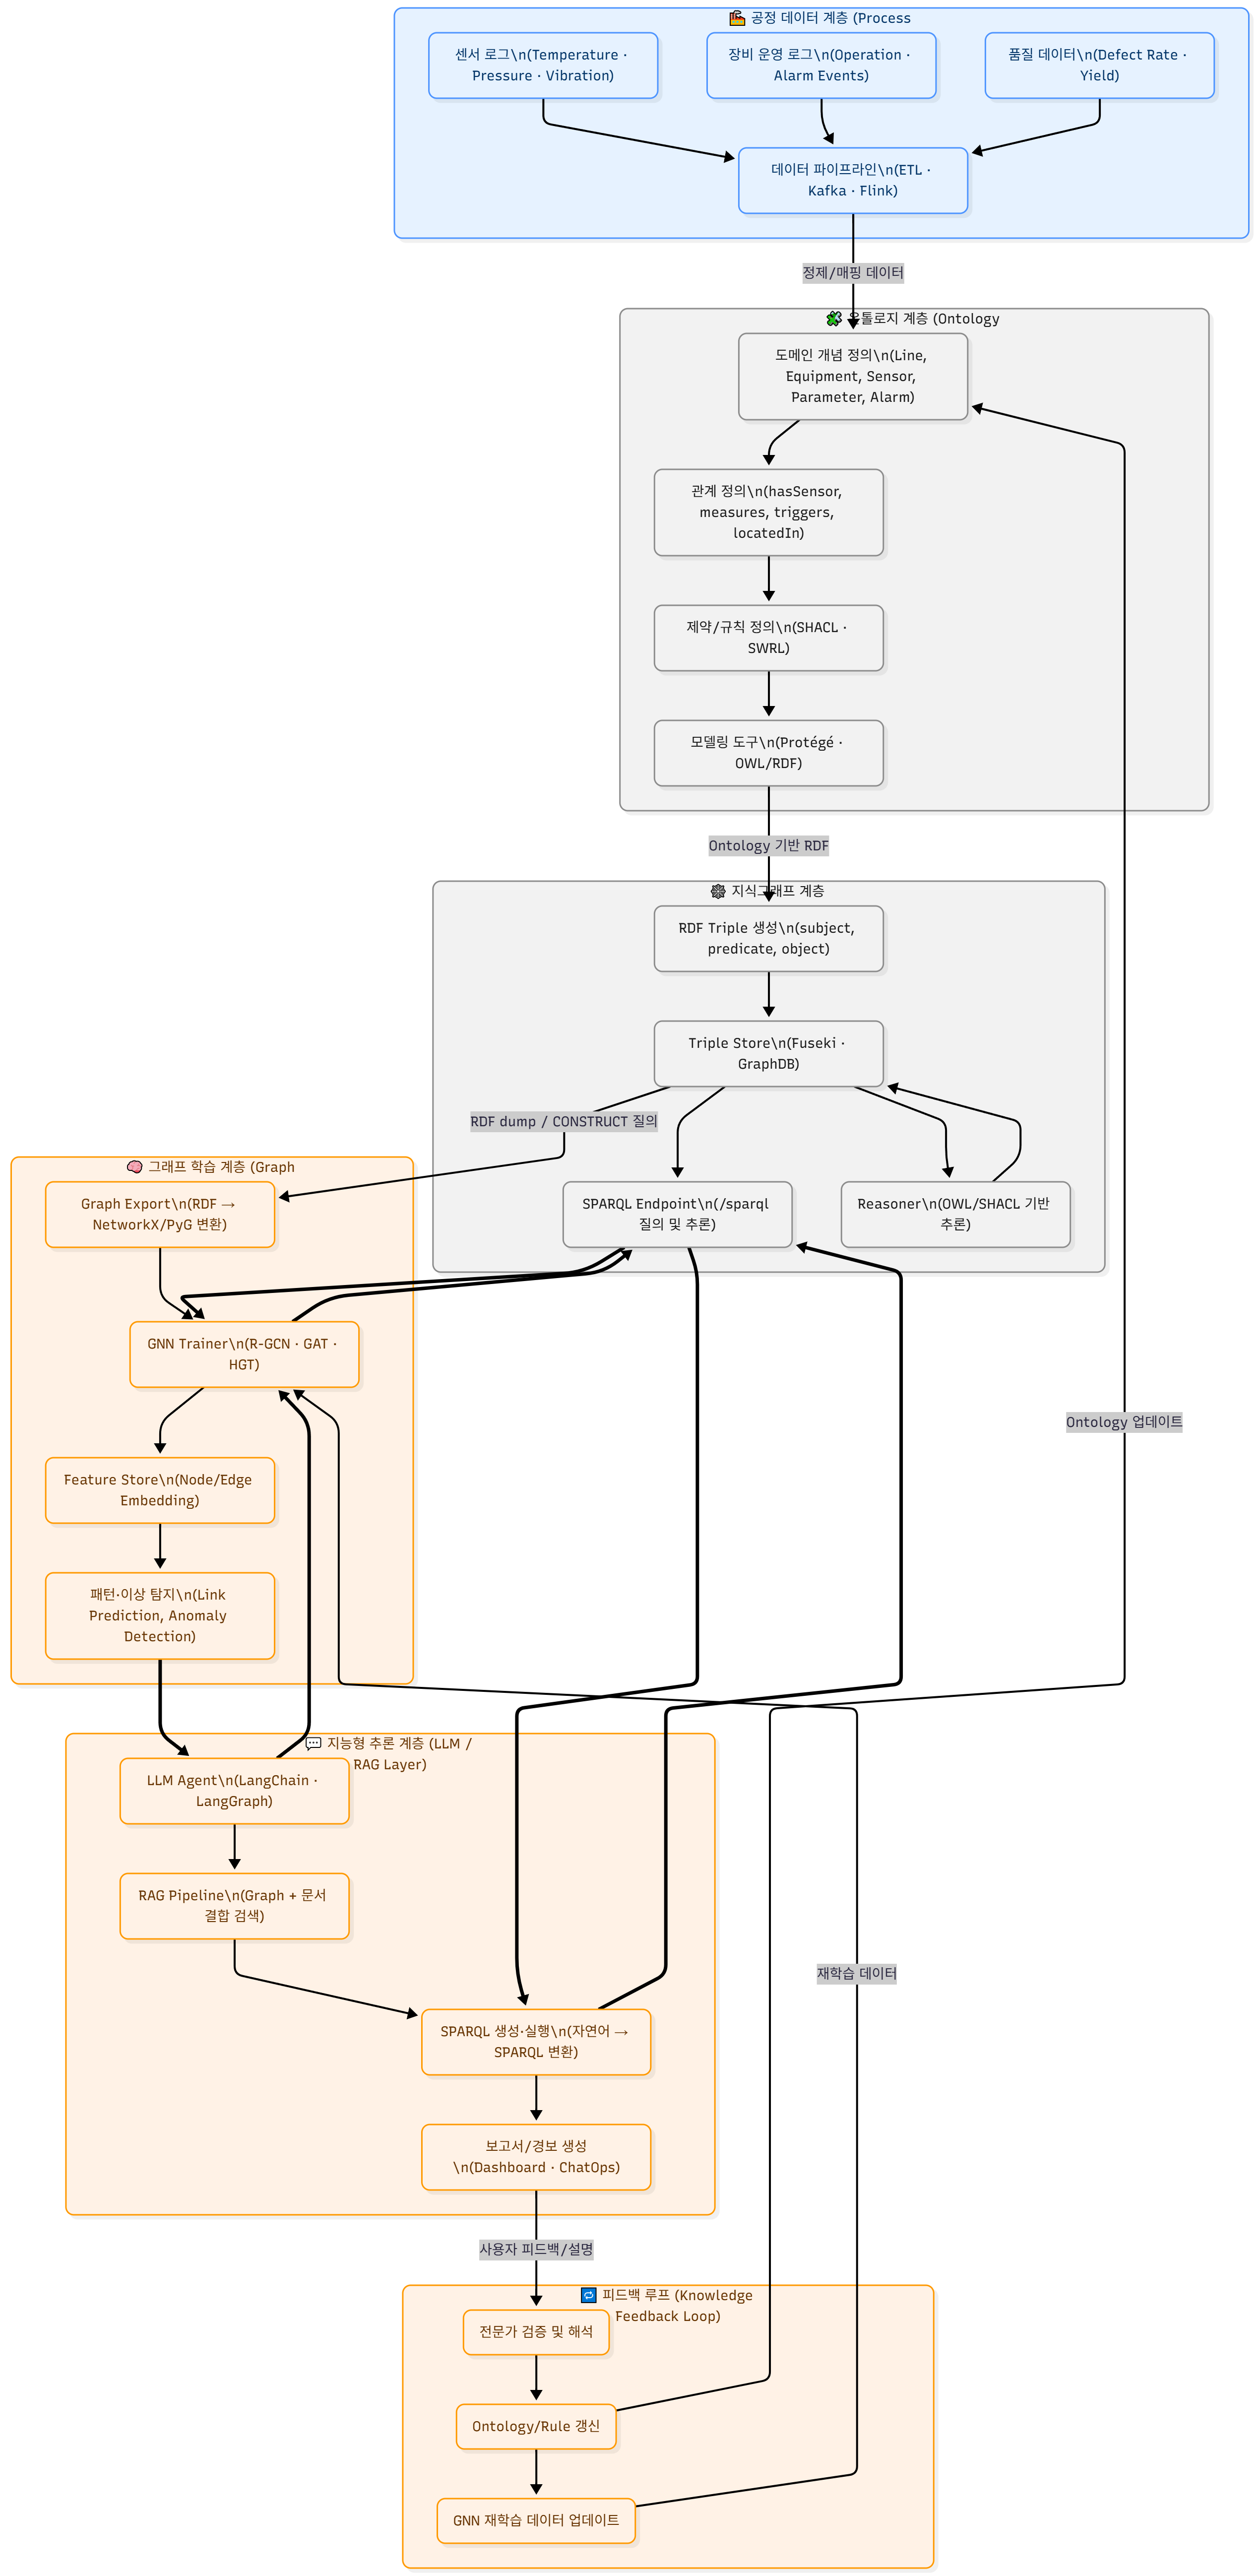

## LLM 하이브리드 RAG 구조 ( SPARQL + 벡터 검색 결합형 RAG 구조 )    
👉 “RDF ↔ VectorStore ↔ GNN ↔ LLM 하이브리드 RAG 구조**” (KG + 임베딩 기반)     

Ontology–Knowledge Graph–GNN–LLM 파이프라인에
새로운 축으로 **Vector Store (임베딩 기반 RAG 검색)** 을 결합한 하이브리드 구조   

* SPARQL → 구조적 관계 질의

* Vector Store → 의미적 유사성 검색  
두 가지를 RAG + GNN + LLM 이 모두 활용하는 **산업용 지식·패턴 융합형 AI 시스템**을 표혐 함


🧩 핵심 포인트  

| 축                        | 역할                           | 핵심 기술                      |
| ------------------------ | ---------------------------- | -------------------------- |
| **SPARQL (구조적 검색)**      | 논리적 관계 추론, Ontology 기반 정밀 질의 | Fuseki, GraphDB            |
| **Vector Store (의미 검색)** | 의미적 유사성 기반 문서·노드 검색          | Milvus, Weaviate, Pinecone |
| **GNN (그래프 학습)**         | 관계 패턴·이상 탐지                  | R-GCN, HGT                 |
| **LLM (언어 이해)**          | 자연어 질의, 통합 추론, 결과 설명         | LangChain, LangGraph       |
| **Feedback Loop**        | 지식·규칙 갱신, 지속적 개선             | Human-in-the-loop          |

🔄 하이브리드 데이터 흐름  

    공정데이터 → Ontology → Knowledge Graph
      ↘︎ 텍스트화 → Vector Store
        ↘︎ (SPARQL + Vector) → Hybrid RAG → GNN → LLM
          ↘︎ 결과 설명 및 Ontology 갱신 → 지속적 개선


| 색상                                        | 의미 |
| ----------------------------------------- | -- |
| 💙 **파랑** → 데이터 안정성 / 신뢰성                 |    |
| ⚪ **회색** → 구조적 지식 (Ontology / KG)         |    |
| 🟩 **연녹색** → 의미 검색 / 임베딩 (Vector Store)   |    |
| 🟧 **주황** → 지능적 처리 (GNN / LLM / Feedback) |    |


In [ ]:
# flowchart TD
# %% ===== 스타일 정의 =====
# classDef data fill:#e6f2ff,stroke:#4d94ff,color:#003366,stroke-width:1.5,rx:10,ry:10
# classDef model fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:10,ry:10
# classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:10,ry:10
# classDef hybrid fill:#e8ffe8,stroke:#66cc66,color:#004d00,stroke-width:1.5,rx:10,ry:10

# %% ===== 1) DATA INGESTION =====
# subgraph A["🏭 **공정 데이터 계층 (Process Data Layer)**"]
# direction TB
# A1["📡 센서 로그\n(Temperature · Pressure · Vibration)"]
# A2["⚙️ 장비 로그\n(Operation · Alarm Events)"]
# A3["🧾 품질 데이터\n(Defect Rate · Yield)"]
# A4["🔄 데이터 파이프라인\n(ETL · Kafka · Flink)"]
# A1 --> A4
# A2 --> A4
# A3 --> A4
# end
# class A,A1,A2,A3,A4 data

# %% ===== 2) ONTOLOGY =====
# subgraph B["🧩 **온톨로지 계층 (Ontology Layer)**"]
# direction TB
# B1["📘 개념 정의\n(Line, Equipment, Sensor, Parameter, Alarm)"]
# B2["🔗 관계 정의\n(hasSensor, measures, triggers)"]
# B3["⚖️ 규칙/제약 정의\n(SHACL · SWRL)"]
# B4["🧰 모델링 도구\n(Protégé · OWL/RDF)"]
# B1 --> B2 --> B3 --> B4
# end
# class B,B1,B2,B3,B4 model

# A4 -->|정제/매핑 데이터| B1

# %% ===== 3) KNOWLEDGE GRAPH =====
# subgraph C["🕸️ **지식그래프 계층 (Knowledge Graph Layer)**"]
# direction TB
# C1["📄 RDF Triple 생성\n(subject, predicate, object)"]
# C2["💾 Triple Store\n(Fuseki · GraphDB)"]
# C3["🔍 SPARQL Endpoint\n(/sparql)"]
# C4["🧮 Reasoner\n(OWL/SHACL 추론)"]
# C1 --> C2 --> C3
# C4 --> C2
# C2 --> C4
# end
# class C,C1,C2,C3,C4 model

# B4 -->|Ontology 기반 RDF| C1

# %% ===== 4) VECTOR STORE =====
# subgraph V["🧭 **Vector Store 계층 (Semantic Embedding Layer)**"]
# direction TB
# V1["🪄 임베딩 생성\n(SentenceTransformers · OpenAI Embedding)"]
# V2["🗃️ Vector DB\n(Milvus · Weaviate · Pinecone)"]
# V3["🔎 유사도 검색\n(Cosine · MMR)"]
# V1 --> V2 --> V3
# end
# class V,V1,V2,V3 hybrid

# A4 -->|문서/로그 텍스트화| V1
# C2 -->|Triple → 텍스트 변환| V1

# %% ===== 5) GRAPH LEARNING (GNN) =====
# subgraph D["🧠 **그래프 학습 계층 (Graph Learning Layer)**"]
# direction TB
# D1["📤 Graph Export\n(RDF → NetworkX/PyG)"]
# D2["🧮 GNN Trainer\n(R-GCN · HGT · CompGCN)"]
# D3["💾 Feature Store\n(Node/Edge Embedding)"]
# D4["⚠️ 이상 탐지/링크 예측\n(Anomaly Detection · Prediction)"]
# D1 --> D2 --> D3 --> D4
# end
# class D,D1,D2,D3,D4 logic

# C2 -->|RDF dump / CONSTRUCT| D1

# %% ===== 6) LLM / RAG =====
# subgraph E["💬 **지능형 추론 계층 (LLM / Hybrid RAG Layer)**"]
# direction TB
# E1["🤖 LLM Agent\n(LangChain · LangGraph)"]
# E2["🧩 Hybrid Retriever\n(SPARQL + Vector Search 통합)"]
# E3["🧠 RAG Pipeline\n(Context Augmentation)"]
# E4["📊 자연어 보고/설명\n(Dashboard · ChatOps)"]
# E1 --> E2 --> E3 --> E4
# end
# class E,E1,E2,E3,E4 logic

# %% ===== 연결 =====
# %% SPARQL + VECTOR → HYBRID RETRIEVER
# C3 ==> E2
# V3 ==> E2

# %% GNN ↔ LLM (양방향)
# D4 ==> E1
# E1 ==> D2

# %% SPARQL ↔ GNN (양방향)
# C3 ==> D2
# D2 ==> C3

# %% ===== 7) FEEDBACK LOOP =====
# subgraph F["🔁 **피드백 루프 (Knowledge Feedback Loop)**"]
# direction TB
# F1["👨‍🔧 전문가 검증"]
# F2["🧱 Ontology/Rule 업데이트"]
# F3["🔁 데이터/모델 재학습"]
# F1 --> F2 --> F3
# end
# class F,F1,F2,F3 logic

# E4 -->|사용자 피드백| F1
# F2 -->|Ontology 업데이트| B1
# F3 -->|GNN 재학습| D2


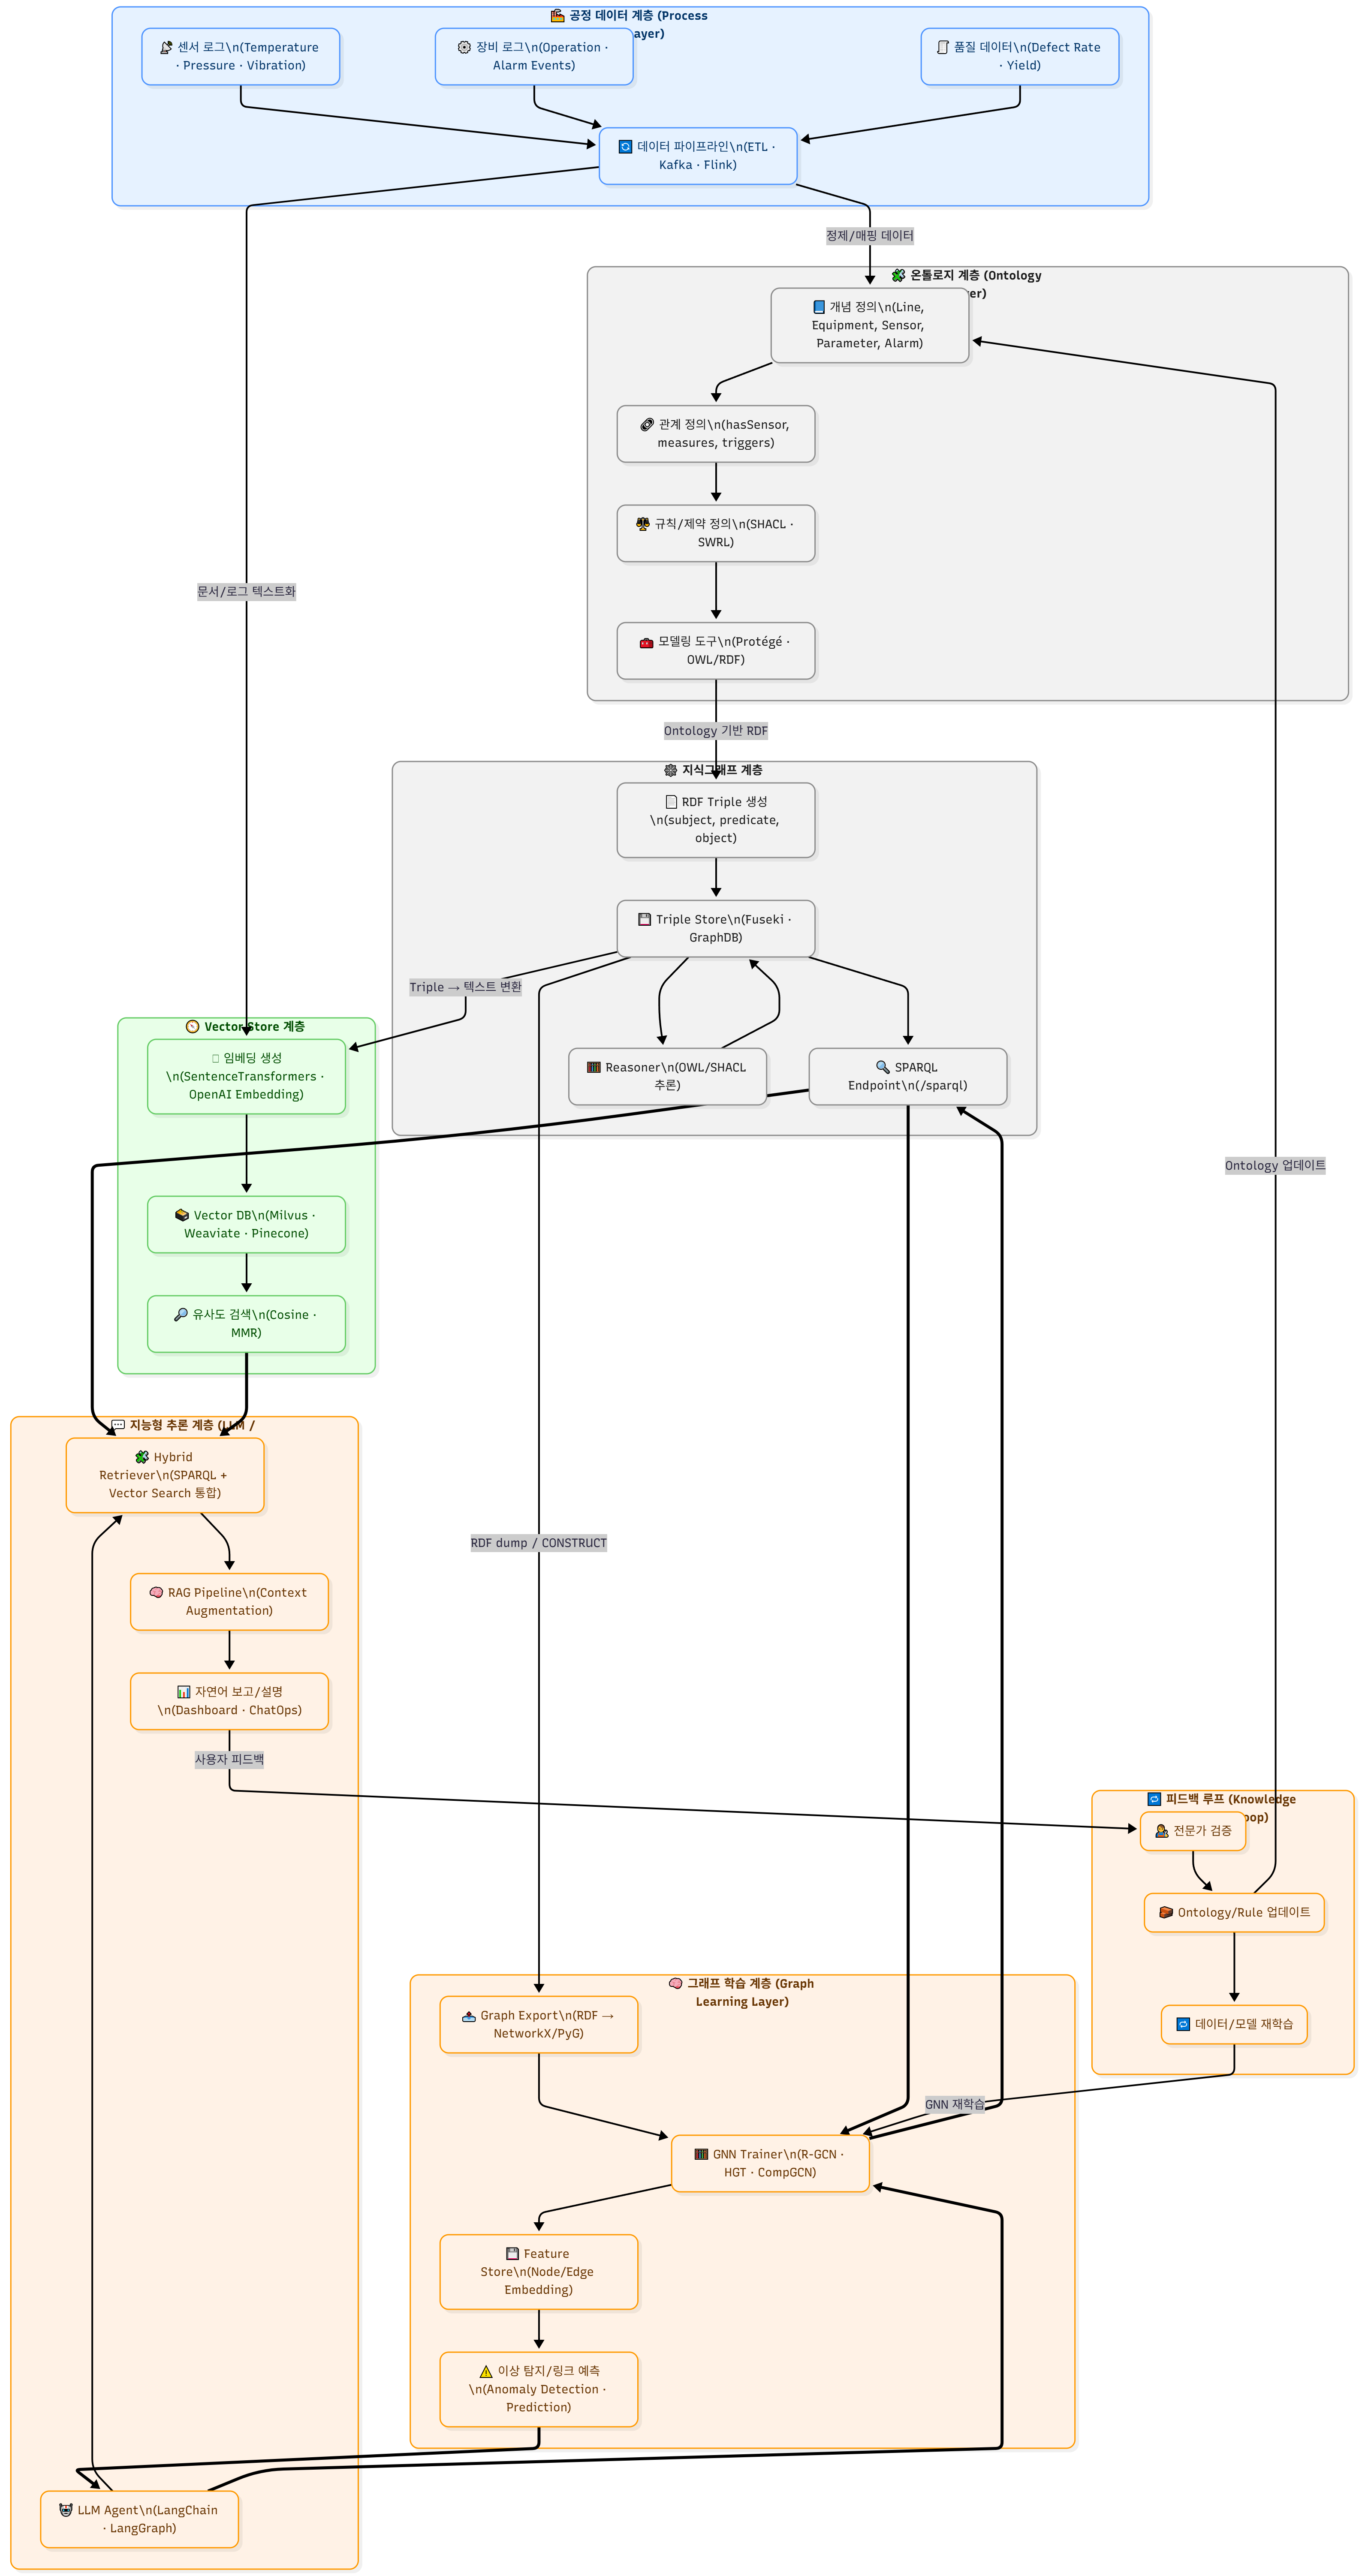

#### 간략화 버전   

해석:  
공정 데이터 → Ontology로 의미화 → KG(SPARQL)와 Vector Store로 저장/검색 → GNN이 구조적 패턴 학습 → LLM이 SPARQL/Vector/GNN 결과를 통합·설명 → Feedback으로 지식·룰 갱신   

    Planner가 질의 의도/정보부족을 판단해 SPARQL / Vector / GNN 중 단일 또는 조합을 선택하고,  
    각 도구의 결과를 Merge/Ranker가 통합 → LLM이 근거와 함께 답변 생성하고,  
    만족도/근거 확인 후, 필요 시 재계획 루프를 실행함.  
    결과는 Feedback Writer를 통해 룰/지식 개선으로 system에 feedback됨.

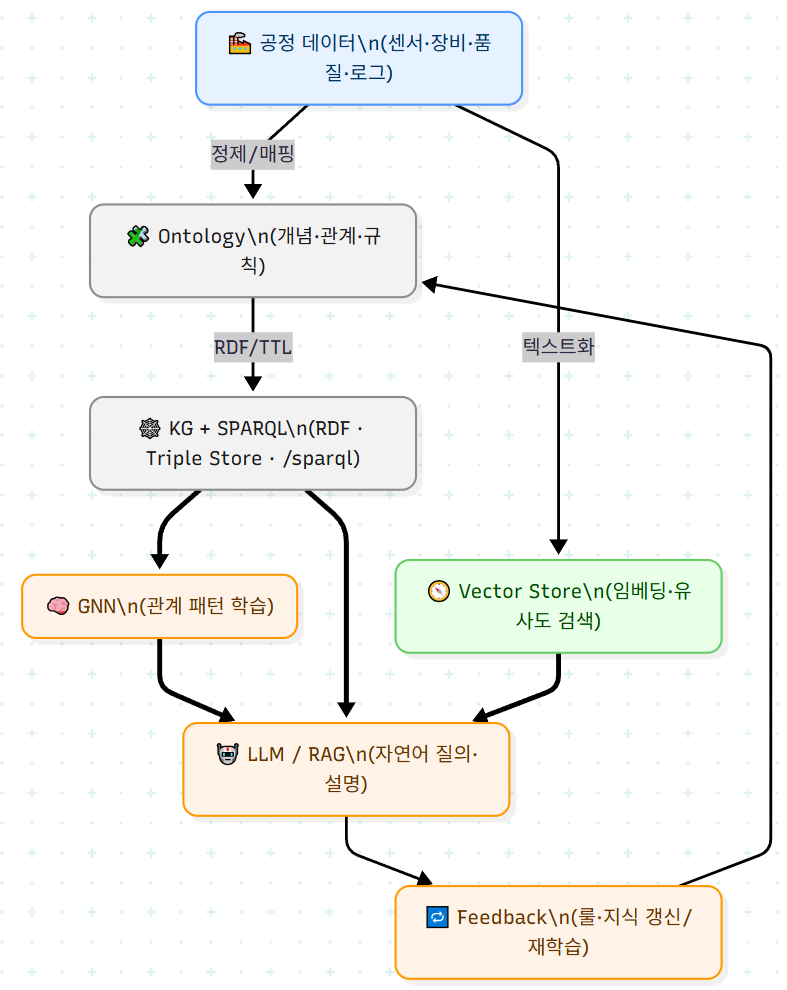

## LangGraph 기반 Agent Workflow   
(SPARQL Tool + Vector Retriever + GNN Analyzer)  

요점:

* Planner가 질의 의도/정보부족을 판단해 SPARQL / Vector / GNN 중 단일 또는 조합을 선택
* 각 도구의 결과를 Merge/Ranker가 통합 → LLM이 근거와 함께 답변 생성
* 만족도/근거 확인 후, 필요 시 재계획 루프
* 결과는 Feedback Writer를 통해 룰/지식 개선으로 환류

In [ ]:
# flowchart TD
#   %% 색상
#   classDef ctrl  fill:#eef7ff,stroke:#7fb3ff,color:#0b2e59,stroke-width:1.5,rx:10,ry:10
#   classDef tool  fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:10,ry:10
#   classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:10,ry:10
#   classDef out   fill:#e8ffe8,stroke:#66cc66,color:#004d00,stroke-width:1.5,rx:10,ry:10

#   %% 단계
#   U["🧑‍🏭 사용자 질의"]:::ctrl
#   O["🧭 Orchestrator\n(LangGraph Runtime)"]:::ctrl
#   P["📝 Planner 노드\n(의도·정보부족·도구선택)"]:::ctrl
#   D{"🔀 라우팅 결정\n(KG? 의미검색? 예측? 다중조합)"}:::ctrl

#   S["🔎 SPARQL Tool\n(/sparql 질의)"]:::tool
#   R["🧭 Vector Retriever\n(임베딩·MMR)"]:::tool
#   N["🧠 GNN Analyzer\n(링크예측·이상탐지)"]:::tool

#   M["🧩 Merge/Ranker\n(결과 통합·중복제거)"]:::logic
#   C["🧠 LLM Synthesizer\n(근거+해설 생성)"]:::logic
#   H{"✅ 만족도/근거 충족?"}:::ctrl
#   F["🔁 Feedback Writer\n(SHACL/SWRL 개선·KG 업데이트 제안)"]:::out
#   RPT["📊 최종 응답\n(요약·표·근거 링크)"]:::out

#   %% 플로우
#   U --> O --> P --> D
#   D -->|구조적 관계 필요| S
#   D -->|문서/로그 의미검색| R
#   D -->|예측/패턴 필요| N

#   %% 병렬/조합 허용
#   S --> M
#   R --> M
#   N --> M

#   M --> C
#   C --> H
#   H -->|No| P
#   %% 부족하면 재계획/재요청
#   H -->|Yes| RPT
#   RPT --> F

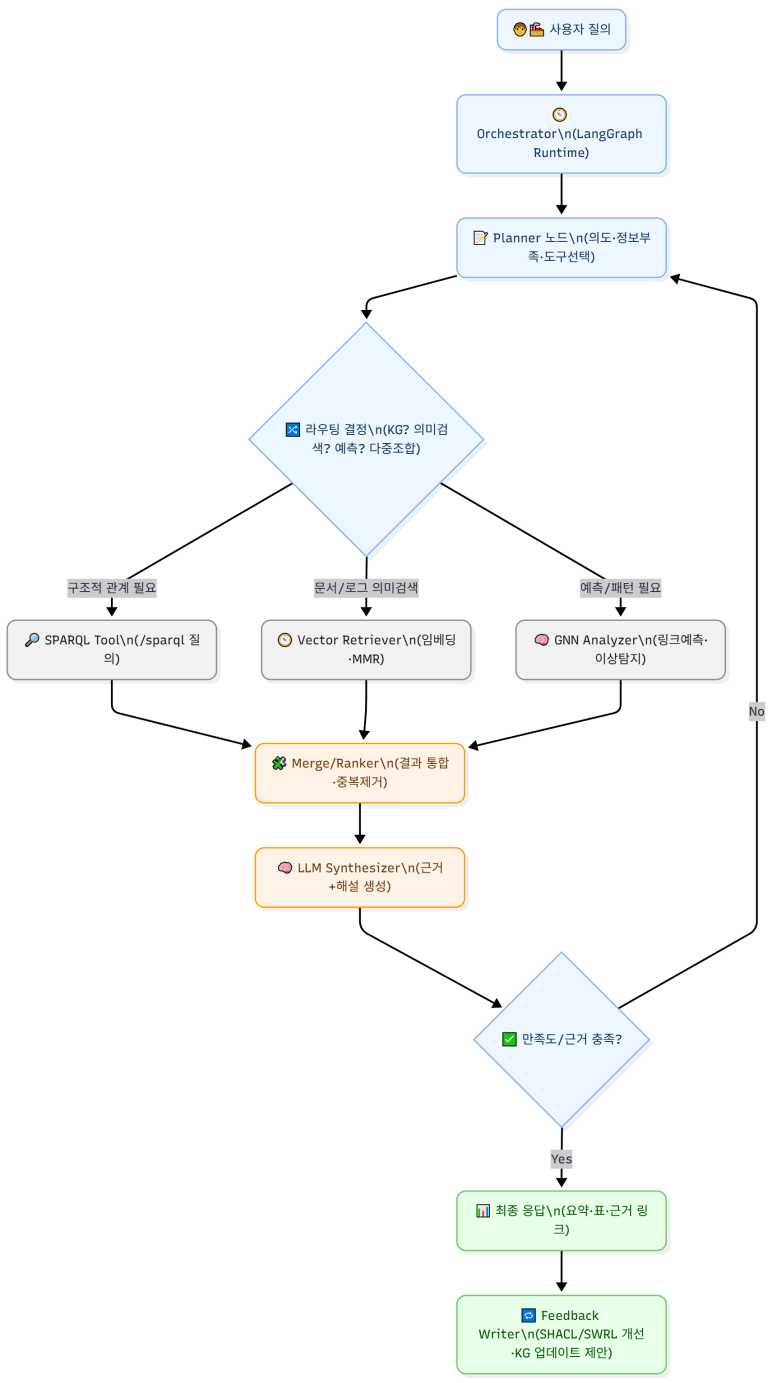

## Agent Workflow 개선(타임아웃·재시도+ Cache(Embedding/KG Query)

이전 LangGraph 기반 Agent Workflow를 유지하면서,

두 가지 운영에 필요한 레이어를 추가한 확장 버전:  

✅ 노드별 타임아웃·재시도 정책 표시  
✅ 캐시 계층 (Embedding Cache / KG Query Cache)   

실제 운영에 적합한 Agent 설계도를 제시 함.  
* 실시간 질의 대응,
* 캐시 기반 저지연 처리,
* 타임아웃/재시도 자동 복구.




💡 주요 변경점  
| 구성          | 추가 내용                                           |
| ----------- | ----------------------------------------------- |
| **캐시 계층**   | 두 개의 독립 캐시 노드: `Vector Cache`, `KG Query Cache` |
| **노드별 정책**  | `timeout`, `retry` 수를 노드 내 주석 형태로 명시            |
| **라우팅 흐름**  | SPARQL/Vector 요청 시 먼저 캐시 확인 후 도구 실행             |
| **캐시 업데이트** | 결과가 새로 생성될 경우 캐시에 저장 (재사용성 향상)                  |



⚙️ 운영 로직 개요

1. 사용자 질의 → Planner가 의도를 분석

2. **라우팅 노드(D)**에서  
KG 기반 질의라면 KG Query Cache → SPARQL Tool  
의미 검색이면 Vector Cache → Vector Retriever  
예측·분석이면 직접 GNN Analyzer 실행  
3. 결과를 Merge/Ranker가 통합하고  
LLM Synthesizer가 설명·보고서를 생성
4. 결과 만족도 체크 후, Feedback Writer로 지식 갱신 제안

🧭 구조 요약  
| 영역                             | 주요 역할                    |
| ------------------------------ | ------------------------ |
| **Orchestrator / Planner**     | LangGraph 실행 제어, 라우팅     |
| **Cache Layer**                | 응답 지연 최소화, 비용 절감         |
| **SPARQL / Vector / GNN Tool** | 각기 다른 검색·예측 엔진           |
| **LLM Synthesizer**            | 결과 요약·근거 설명              |
| **Feedback Writer**            | 지식·규칙 개선 제안 (SHACL/SWRL) |



In [ ]:
# flowchart TD
#   %% 색상 정의
#   classDef ctrl  fill:#eef7ff,stroke:#7fb3ff,color:#0b2e59,stroke-width:1.5,rx:10,ry:10
#   classDef tool  fill:#f2f2f2,stroke:#8c8c8c,color:#1a1a1a,stroke-width:1.5,rx:10,ry:10
#   classDef logic fill:#fff2e6,stroke:#ff9900,color:#663300,stroke-width:1.5,rx:10,ry:10
#   classDef cache fill:#e8ffe8,stroke:#66cc66,color:#004d00,stroke-width:1.5,rx:10,ry:10
#   classDef out   fill:#fffbea,stroke:#ffd27f,color:#4d3b00,stroke-width:1.5,rx:10,ry:10

#   %% 단계
#   U["🧑‍🏭 사용자 질의"]:::ctrl
#   O["🧭 Orchestrator\n(LangGraph Runtime)"]:::ctrl
#   P["📝 Planner 노드\n(의도 분석 · 도구 선택)"]:::ctrl
#   D{"🔀 라우팅 결정\n(KG / 의미검색 / 예측)"}:::ctrl

#   %% 캐시 계층
#   subgraph Cache["🧠 캐시 계층 (Cache Layer)"]
#   direction TB
#   VC["💾 Vector Cache\n(임베딩·검색결과 캐시)"]:::cache
#   KC["🗄️ KG Query Cache\n(SPARQL 결과 캐시)"]:::cache
#   end

#   %% 도구 노드
#   S["🔎 SPARQL Tool\n(/sparql 질의)\n⏱️ timeout=8s · retry=2"]:::tool
#   R["🧭 Vector Retriever\n(임베딩 검색)\n⏱️ timeout=5s · retry=1"]:::tool
#   N["🧠 GNN Analyzer\n(링크예측·이상탐지)\n⏱️ timeout=12s · retry=1"]:::tool

#   %% 로직 노드
#   M["🧩 Merge/Ranker\n(결과 통합·중복제거)"]:::logic
#   C["🧠 LLM Synthesizer\n(근거+설명 생성)\n⏱️ timeout=15s · retry=1"]:::logic
#   H{"✅ 근거 충족 여부"}:::ctrl
#   F["🔁 Feedback Writer\n(룰/지식 갱신 제안)"]:::out
#   RPT["📊 최종 응답\n(요약·근거 링크)"]:::out

#   %% 흐름
#   U --> O --> P --> D

#   %% 캐시 체크 후 도구 호출
#   D -->|구조적 질의| KC --> S
#   D -->|의미 검색| VC --> R
#   D -->|예측/패턴| N

#   %% 병렬 결과 병합
#   S --> M
#   R --> M
#   N --> M

#   %% 응답 생성 및 검증
#   M --> C --> H
#   H -->|No| P
#   H -->|Yes| RPT
#   RPT --> F

#   %% 캐시 업데이트 경로
#   S -->|결과 저장| KC
#   R -->|임베딩 저장| VC


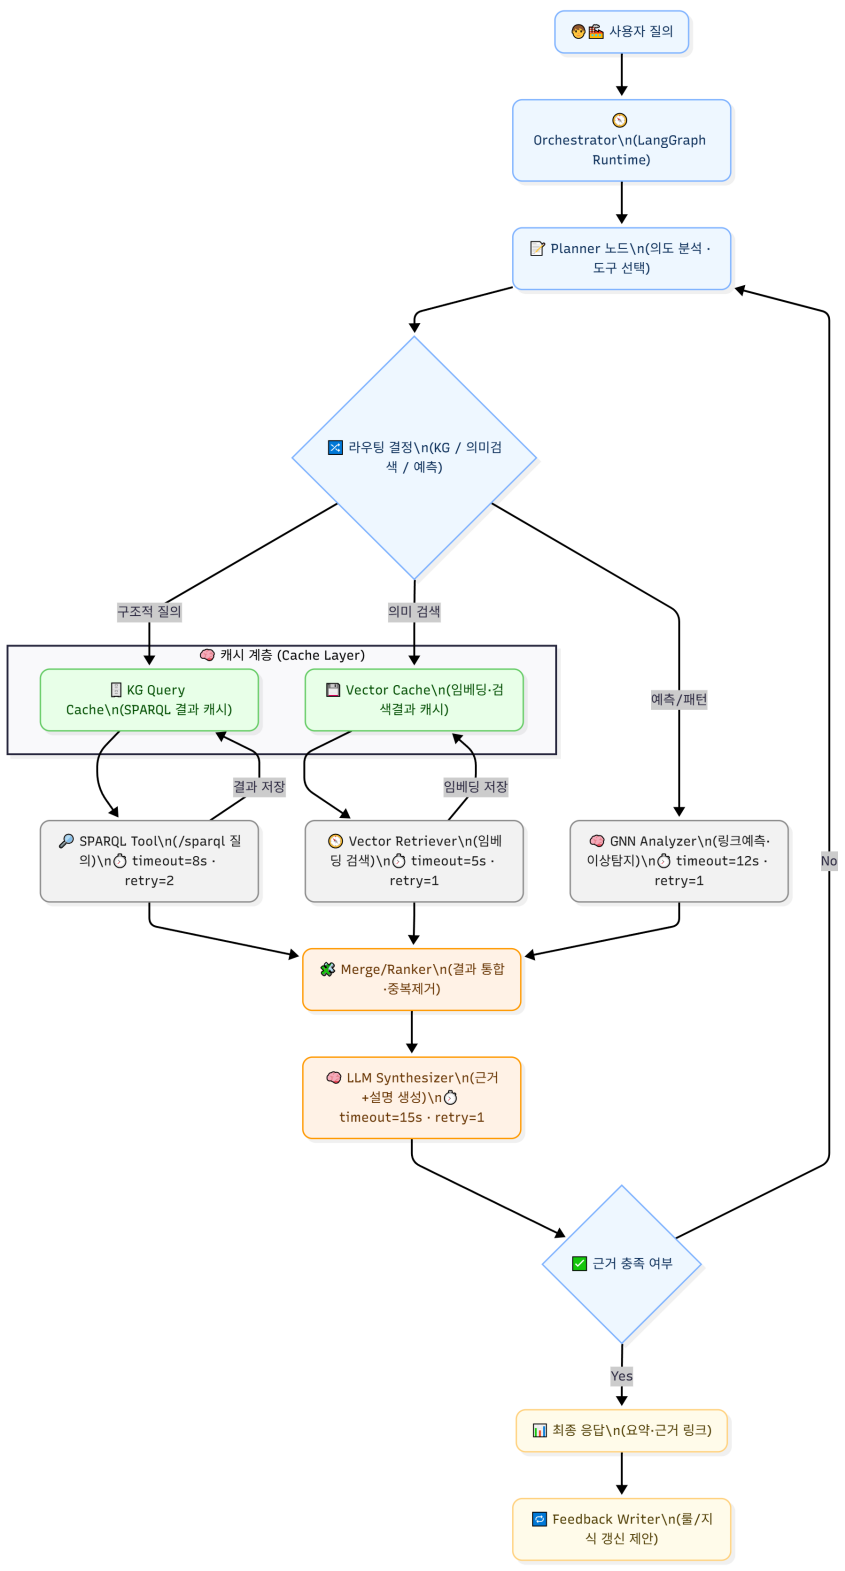